In [2]:
# Installing necessary libraries
!pip install yfinance matplotlib seaborn statsmodels scikit-learn

# Imports
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Download data for Amazon (ticker 'AMZN')
start_date = '2012-01-01'
end_date = '2024-10-31'

data = yf.download('AMZN', start=start_date, end=end_date, progress=False)
data = data.resample('ME').last()  # Month End
data = data[['Close']]
data.dropna(inplace=True)
print(data.head())
print(data.shape)

Price         Close
Ticker         AMZN
Date               
2012-01-31   9.7220
2012-02-29   8.9845
2012-03-31  10.1255
2012-04-30  11.5950
2012-05-31  10.6455
(154, 1)


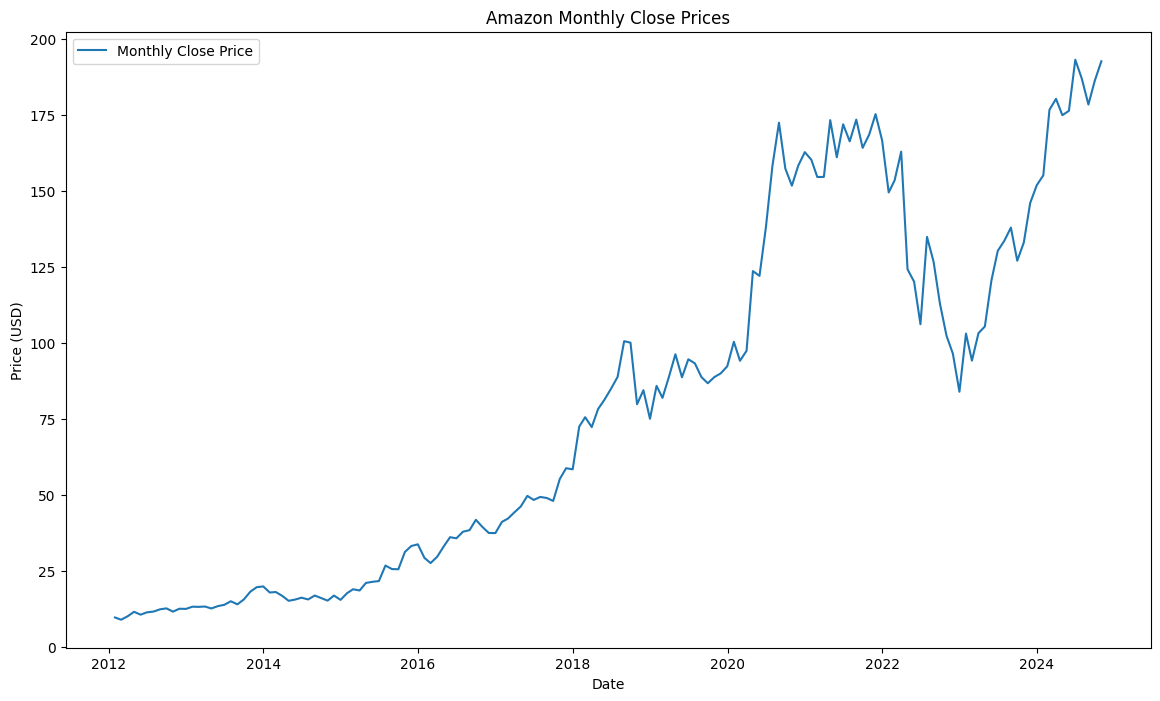

In [18]:
# plotting the monthly closing prices

plt.figure(figsize=(14, 8))
plt.plot(data['Close'], label='Monthly Close Price')
plt.title('Amazon Monthly Close Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


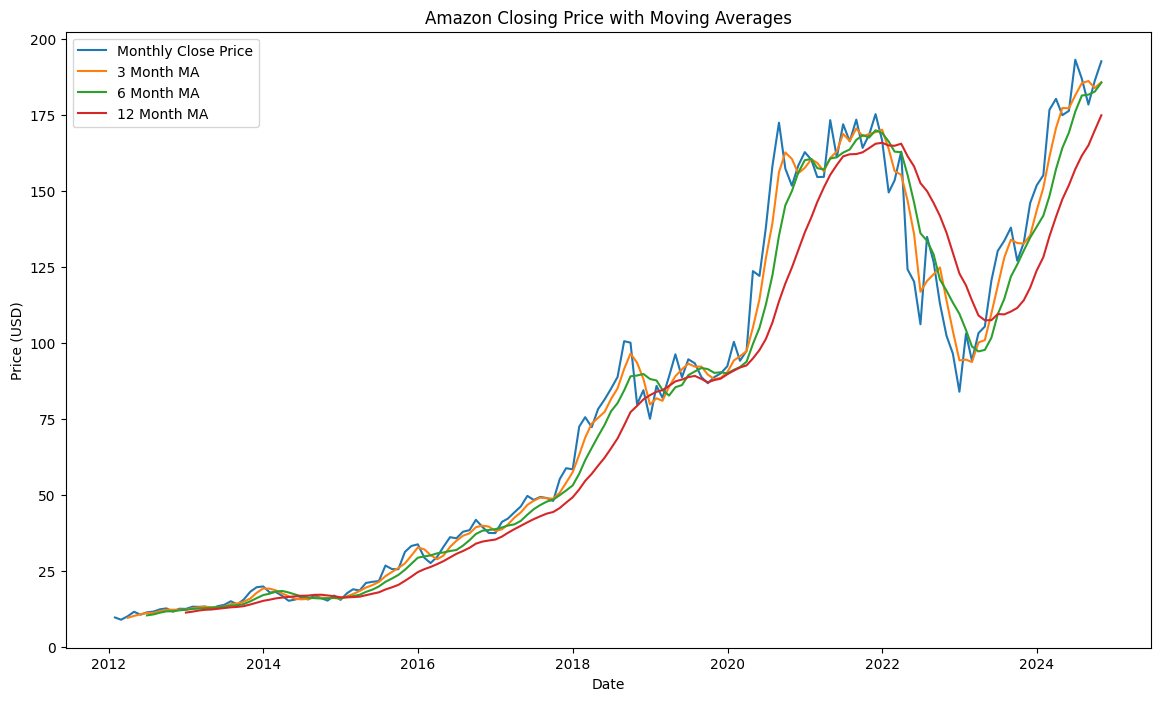

In [19]:
# calculating 3, 6, 12-month moving averages

data['3_month_MA'] = data['Close'].rolling(window=3).mean()
data['6_month_MA'] = data['Close'].rolling(window=6).mean()
data['12_month_MA'] = data['Close'].rolling(window=12).mean()

plt.figure(figsize=(14, 8))
plt.plot(data['Close'], label='Monthly Close Price')
plt.plot(data['3_month_MA'], label='3 Month MA')
plt.plot(data['6_month_MA'], label='6 Month MA')
plt.plot(data['12_month_MA'], label='12 Month MA')
plt.title('Amazon Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


In [20]:
# Augmented Dickey-Fuller Test for checking stationarity

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Series is Stationary")
    else:
        print("Series is Non-Stationary")

adf_test(data['Close'])

# First differencing if non-stationary
data['Close_diff'] = data['Close'].diff().dropna()
adf_test(data['Close_diff'].dropna())


ADF Statistic: -0.45822203358685243
p-value: 0.8999145949252203
Series is Non-Stationary
ADF Statistic: -4.92928149571886
p-value: 3.0575157318213284e-05
Series is Stationary


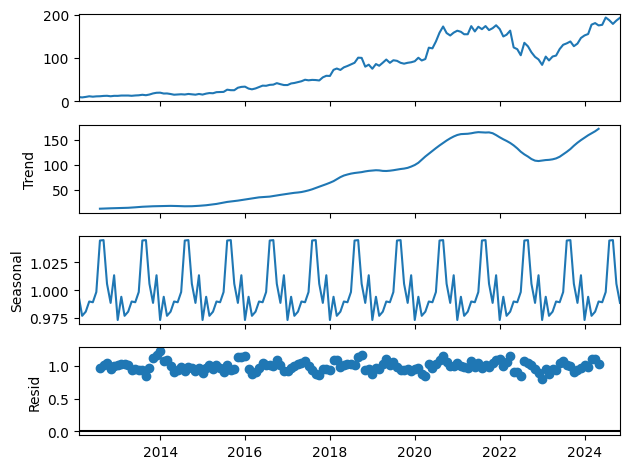

In [21]:

# Seasonal decomposition of the time series

decompose_result = seasonal_decompose(data['Close'], model='multiplicative', period=12)
decompose_result.plot()
plt.show()


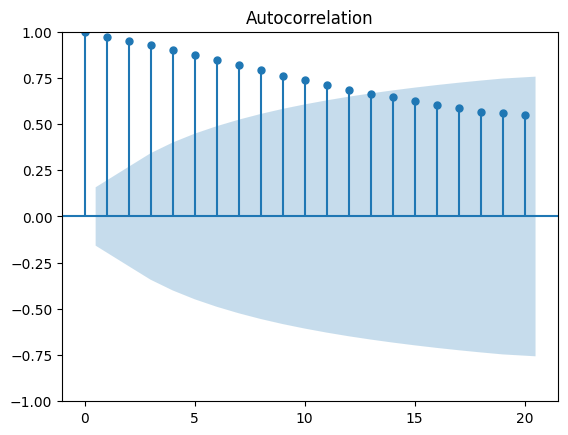

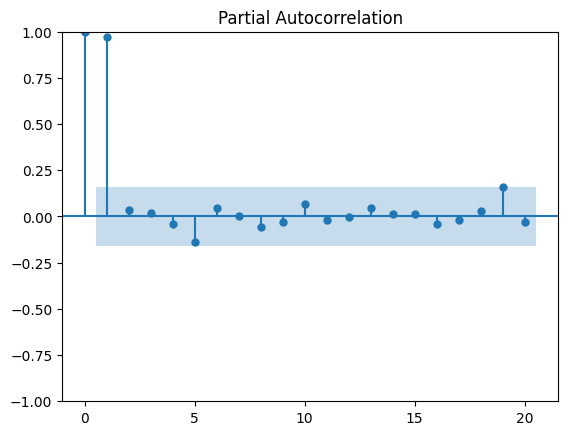

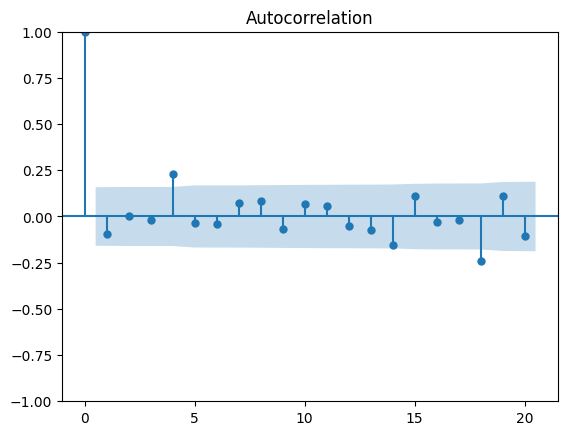

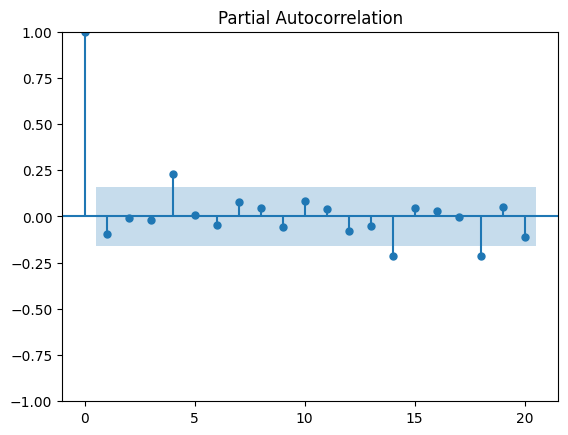

In [22]:
# Plot ACF and PACF Before differencing

plot_acf(data['Close'].dropna(), lags=20)
plt.show()

plot_pacf(data['Close'].dropna(), lags=20)
plt.show()

# Plot ACF and PACF After differencing
plot_acf(data['Close_diff'].dropna(), lags=20)
plt.show()

plot_pacf(data['Close_diff'].dropna(), lags=20)
plt.show()


In [23]:
# Train-Test split 

train_data = data['Close'][:int(len(data)*0.8)]
test_data = data['Close'][int(len(data)*0.8):]


In [24]:

# Automatic SARIMA Fitting with Grid Search

from statsmodels.tsa.statespace.sarimax import SARIMAX

def auto_sarima(train_data, seasonal_period=12):
    best_aic = np.inf
    best_order = None
    best_seasonal_order = None
    best_model = None

    for p in range(3):
        for d in range(2):
            for q in range(3):
                for P in range(3):
                    for D in range(2):
                        for Q in range(3):
                            try:
                                model = SARIMAX(train_data,
                                                order=(p,d,q),
                                                seasonal_order=(P,D,Q,seasonal_period),
                                                enforce_stationarity=False,
                                                enforce_invertibility=False)
                                results = model.fit(disp=False)
                                if results.aic < best_aic:
                                    best_aic = results.aic
                                    best_order = (p,d,q)
                                    best_seasonal_order = (P,D,Q,seasonal_period)
                                    best_model = results
                                    print(f"SARIMA Order: {best_order}, Seasonal Order: {best_seasonal_order}, AIC: {best_aic}")
                            except:
                                continue
    print(f"\nBest SARIMA Order: {best_order}, Seasonal Order: {best_seasonal_order}, AIC: {best_aic}")
    return best_model

sarima_model = auto_sarima(train_data)


SARIMA Order: (0, 0, 0), Seasonal Order: (0, 0, 0, 12), AIC: 1431.4100681964758
SARIMA Order: (0, 0, 0), Seasonal Order: (0, 0, 1, 12), AIC: 1202.7721562942213
SARIMA Order: (0, 0, 0), Seasonal Order: (0, 0, 2, 12), AIC: 1039.3761816991882
SARIMA Order: (0, 0, 0), Seasonal Order: (0, 1, 0, 12), AIC: 1028.3367587220853
SARIMA Order: (0, 0, 0), Seasonal Order: (0, 1, 1, 12), AIC: 924.2401597773073
SARIMA Order: (0, 0, 0), Seasonal Order: (0, 1, 2, 12), AIC: 797.386148549626
SARIMA Order: (0, 0, 0), Seasonal Order: (1, 1, 2, 12), AIC: 750.6146527415124
SARIMA Order: (0, 0, 0), Seasonal Order: (2, 1, 1, 12), AIC: 716.8693267692045
SARIMA Order: (0, 0, 0), Seasonal Order: (2, 1, 2, 12), AIC: 710.0263505149162
SARIMA Order: (0, 0, 1), Seasonal Order: (0, 1, 2, 12), AIC: 709.644900061786
SARIMA Order: (0, 0, 1), Seasonal Order: (1, 1, 2, 12), AIC: 674.8874101161259
SARIMA Order: (0, 0, 1), Seasonal Order: (2, 1, 1, 12), AIC: 668.5355703745148
SARIMA Order: (0, 0, 2), Seasonal Order: (0, 1, 2,

In [30]:
# SARIMA Forecasting

sarima_forecast = sarima_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, dynamic=False)

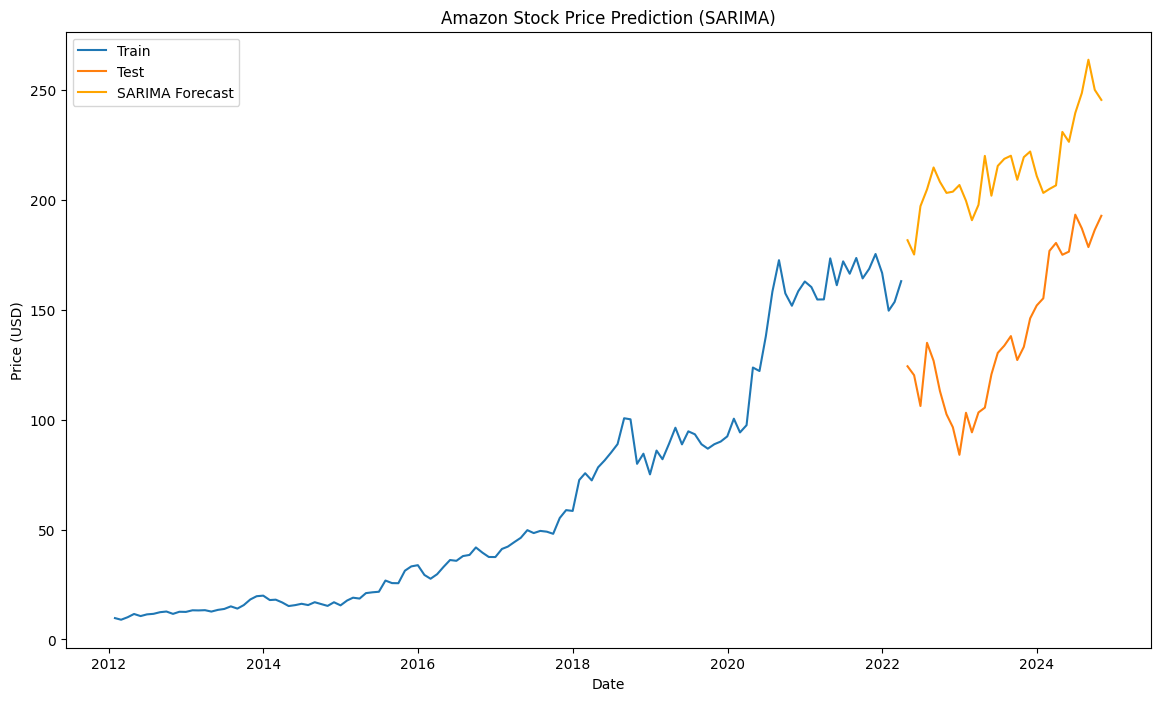

In [31]:
# Plot SARIMA results
plt.figure(figsize=(14, 8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(sarima_forecast, label='SARIMA Forecast', color='orange')
plt.title('Amazon Stock Price Prediction (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [32]:
# RMSE & MAE

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Convert Series to numpy arrays (ensure same shape)
y_true = test_data.values
y_pred = sarima_forecast.values

# RMSE manually
sarima_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
sarima_mae = mean_absolute_error(y_true, y_pred)

print(f'SARIMA RMSE: {sarima_rmse}')
print(f'SARIMA MAE: {sarima_mae}')

SARIMA RMSE: 79.14674309268771
SARIMA MAE: 75.56967340707243


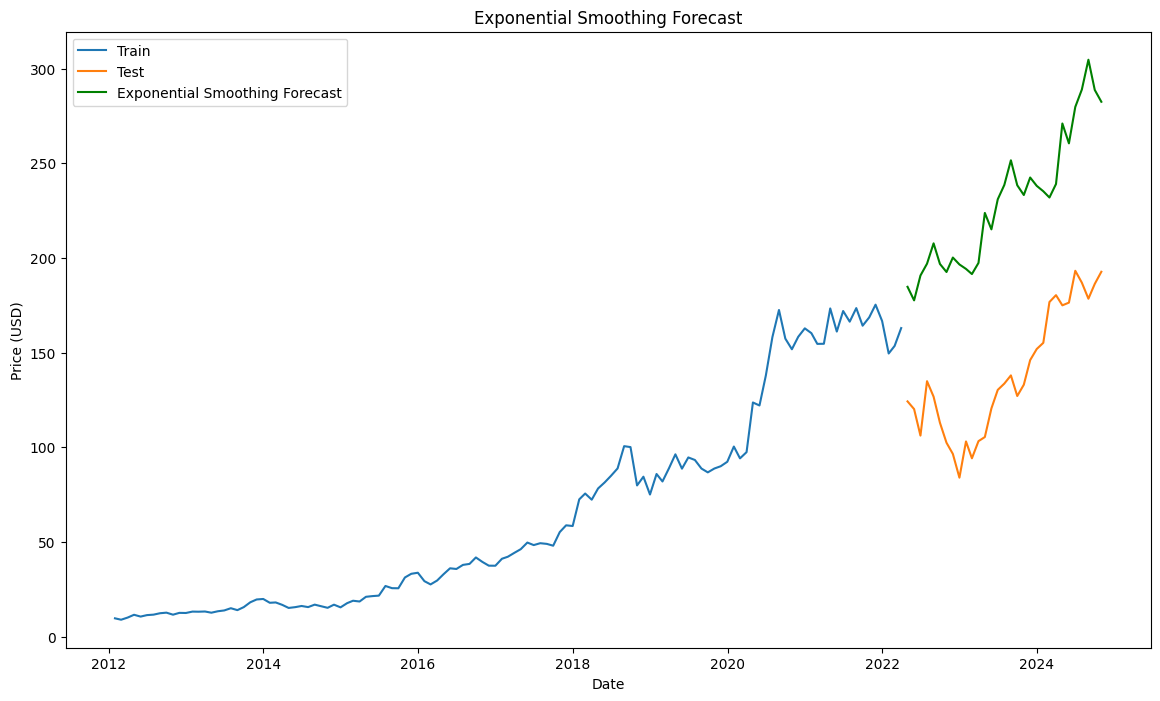

In [28]:
# Exponential Smoothing (Holt-Winters Method)

def exponential_smoothing(train_data, test_data):
    model = ExponentialSmoothing(train_data, trend='mul', seasonal='mul', seasonal_periods=12)
    model_fit = model.fit()
    forecast = model_fit.forecast(len(test_data))
    
    plt.figure(figsize=(14, 8))
    plt.plot(train_data, label='Train')
    plt.plot(test_data, label='Test')
    plt.plot(forecast, label='Exponential Smoothing Forecast', color='green')
    plt.title('Exponential Smoothing Forecast')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()
    
    return forecast


# Apply Exponential Smoothing Model    

exp_smoothing_forecast = exponential_smoothing(train_data, test_data)

In [29]:
# Calculate RMSE and MAE for Exponential Smoothing

exp_smoothing_rmse = np.sqrt(mean_squared_error(test_data.values, exp_smoothing_forecast.values))
exp_smoothing_mae = mean_absolute_error(test_data.values, exp_smoothing_forecast.values)

print(f'Exponential Smoothing RMSE: {exp_smoothing_rmse}')
print(f'Exponential Smoothing MAE: {exp_smoothing_mae}')

Exponential Smoothing RMSE: 92.87374533235226
Exponential Smoothing MAE: 91.13782586145804


In [27]:

# Comparison of Models

if sarima_rmse < exp_smoothing_rmse:
    print("SARIMA performs better based on RMSE.")
else:
    print("Exponential Smoothing performs better based on RMSE.")

if sarima_mae < exp_smoothing_mae:
    print("SARIMA performs better based on MAE.")
else:
    print("Exponential Smoothing performs better based on MAE.")


SARIMA performs better based on RMSE.
SARIMA performs better based on MAE.
